# EEG Analysis — 3 Subjects
Complete pipeline for preprocessing, feature extraction, and clustering of EEG signals for **3 subjects** (`Datos_user_1`, `Datos_user_2`, `Datos_user_3`).

## Table of Contents
1. Global Configuration
2. Installation of Dependencies
3. File Location
4. Cleaning and Imputation (KNN)
5. Loading Preprocessed Data
6. Frequency Analysis (PSD — Welch)
7. Band-pass Filtering (8–30 Hz)
8. Feature Extraction (Alpha / Beta per window)
9. Normalization and Final Matrix `X`
10. Dimensionality Reduction (PCA · t-SNE · UMAP · Kernel PCA)
11. Clustering: UMAP + K-Means Pipeline (train / test)
12. Evaluation (Silhouette) and Cluster Visualization
13. Final Summary

## 1. Global Configuration
All analysis parameters live here. There are no paths or constants scattered throughout the rest of the notebook.

In [2]:
import os
import glob
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------
# Cambia DIR_ENTRADA por la carpeta donde estén tus 3 CSV.
DIR_ENTRADA = '/content/'
DIR_SALIDA  = '/content/cleaned_data/'

# Nombres de archivos actualizados según tu solicitud
ARCHIVOS_SUJETOS = [
    'datos_limpios_Datos_user_1 (1) (1).csv',
    'datos_limpios_Datos_user_2 (1).csv',
    'datos_limpios_Datos_user_3 (1).csv',
]

# ---------------------------------------------------------------
# PARÁMETROS DE SEÑAL
# ---------------------------------------------------------------
FS               = 249.02   # Frecuencia de muestreo (Hz)
PREFIJO_CANAL    = 'EXG Channel'
BANDA_PASO       = (8.0, 30.0)   # Filtro pasa-banda (Hz)
BANDA_ALFA       = (8, 13)
BANDA_BETA       = (13, 30)
VENTANA_SEG      = 1.0      # Duración de ventana (s)
SOLAPE_SEG       = 0.5      # Paso entre ventanas (s)

# ---------------------------------------------------------------
# PARÁMETROS DEL MODELO
# ---------------------------------------------------------------
N_CLUSTERS       = 5
SEMILLA          = 42
TEST_SIZE        = 0.20
UMAP_NEIGHBORS   = 30
UMAP_MIN_DIST    = 0.1

NOMBRES_MOV = [f'Movimiento {chr(65 + i)}' for i in range(N_CLUSTERS)]
COLORES_MOV = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231']

os.makedirs(DIR_SALIDA, exist_ok=True)
print(f'Entrada : {DIR_ENTRADA}')
print(f'Salida  : {DIR_SALIDA}')
print(f'Sujetos : {len(ARCHIVOS_SUJETOS)}')

Entrada : /content/
Salida  : /content/cleaned_data/
Sujetos : 3


## 2. Dependency Installation
Execute only once per session (Colab).

In [1]:
!pip install -q umap-learn

## 3. File Location
Searches for the 3 CSVs in `DIR_ENTRADA`. If it doesn't find the exact names, it falls back to a `glob` pattern.

In [ ]:
rutas_sujetos = [os.path.join(DIR_ENTRADA, f) for f in ARCHIVOS_SUJETOS]
rutas_sujetos = [r for r in rutas_sujetos if os.path.exists(r)]

if not rutas_sujetos:
    rutas_sujetos = sorted(glob.glob(os.path.join(DIR_ENTRADA, 'datos_limpios_Datos_user_*.csv')))

if not rutas_sujetos:
    raise FileNotFoundError(
        f'No se encontró ningún CSV de sujeto en {DIR_ENTRADA}. '
        'Revisa DIR_ENTRADA y ARCHIVOS_SUJETOS en la celda de configuración.'
    )

print(f'Archivos encontrados ({len(rutas_sujetos)}):')
for r in rutas_sujetos:
    print('  -', r)

## 4. Cleaning and Imputation (KNN)

For each subject:
1. Impute `NaN` from EEG channels using KNN.
2. Remove channels with more than 70% zeros (disconnected electrode).
3. Treat remaining zeros as missing and impute them with KNN.
4. Recombine with non-EEG columns (`Timestamp`, etc.) and save as `*_preprocessed.csv`.

In [3]:
from sklearn.impute import KNNImputer


def limpiar_e_imputar(df, umbral_ceros=70, n_vecinos=5):
    """Limpia un DataFrame EEG: imputa NaN, descarta canales muertos e imputa ceros."""
    df = df.copy()
    print(f'  Forma inicial: {df.shape}')

    canales_eeg = [c for c in df.columns if c.startswith(PREFIJO_CANAL)]
    if not canales_eeg:
        print(f'  Advertencia: no hay columnas "{PREFIJO_CANAL}". Se devuelve sin cambios.')
        return df

    otras_cols = [c for c in df.columns if c not in canales_eeg]

    # Paso 1 — imputar NaN
    eeg = pd.DataFrame(
        KNNImputer(n_neighbors=n_vecinos).fit_transform(df[canales_eeg]),
        columns=canales_eeg, index=df.index,
    )

    # Paso 2 — descartar canales con exceso de ceros
    pct_ceros = (eeg == 0).sum() / len(eeg) * 100
    a_eliminar = pct_ceros[pct_ceros > umbral_ceros].index.tolist()
    if a_eliminar:
        print(f'  Canales eliminados por >{umbral_ceros}% de ceros: {a_eliminar}')
        eeg = eeg.drop(columns=a_eliminar)
    else:
        print('  Ningún canal eliminado.')

    # Paso 3 — imputar ceros restantes
    if not eeg.empty:
        eeg = pd.DataFrame(
            KNNImputer(n_neighbors=n_vecinos).fit_transform(eeg.replace(0, np.nan)),
            columns=eeg.columns, index=eeg.index,
        )

    # Paso 4 — recombinar
    df_final = pd.concat([df[otras_cols], eeg], axis=1)
    print(f'  Forma final: {df_final.shape}')
    return df_final

In [5]:
# Aseguramos que rutas_sujetos esté definida si no se ejecutó la celda anterior
rutas_sujetos = [os.path.join(DIR_ENTRADA, f) for f in ARCHIVOS_SUJETOS]
rutas_sujetos = [r for r in rutas_sujetos if os.path.exists(r)]

if not rutas_sujetos:
    rutas_sujetos = sorted(glob.glob(os.path.join(DIR_ENTRADA, 'datos_limpios_Datos_user_*.csv')))

if not rutas_sujetos:
    print(f'ERROR: No se encontraron archivos en {DIR_ENTRADA}')
else:
    procesados = 0
    for ruta in rutas_sujetos:
        nombre = os.path.basename(ruta).replace('.csv', '').replace(' ', '_')
        print(f'\n--- Limpiando {nombre} ---')
        try:
            df = pd.read_csv(ruta)
            df.columns = df.columns.str.strip()
            df_limpio = limpiar_e_imputar(df)

            destino = os.path.join(DIR_SALIDA, f'{nombre}_preprocesado.csv')
            df_limpio.to_csv(destino, index=False)
            print(f'  Guardado en: {destino}')
            procesados += 1
        except Exception as e:
            print(f'  Error procesando {nombre}: {e}')

    print(f'\nPreprocesamiento completado: {procesados}/{len(rutas_sujetos)} archivos.')


--- Limpiando datos_limpios_Datos_user_1_(1)_(1) ---
  Forma inicial: (164490, 15)
  Ningún canal eliminado.
  Forma final: (164490, 15)
  Guardado en: /content/cleaned_data/datos_limpios_Datos_user_1_(1)_(1)_preprocesado.csv

--- Limpiando datos_limpios_Datos_user_2_(1) ---
  Forma inicial: (164154, 15)
  Ningún canal eliminado.
  Forma final: (164154, 15)
  Guardado en: /content/cleaned_data/datos_limpios_Datos_user_2_(1)_preprocesado.csv

--- Limpiando datos_limpios_Datos_user_3_(1) ---
  Forma inicial: (164912, 15)
  Ningún canal eliminado.
  Forma final: (164912, 15)
  Guardado en: /content/cleaned_data/datos_limpios_Datos_user_3_(1)_preprocesado.csv

Preprocesamiento completado: 3/3 archivos.


## 5. Loading Preprocessed Data

In [6]:
archivos_limpios = sorted(glob.glob(os.path.join(DIR_SALIDA, '*_preprocesado.csv')))
if not archivos_limpios:
    raise FileNotFoundError(f'No hay archivos preprocesados en {DIR_SALIDA}. Ejecuta la sección 4.')

subjects_data = {}
for ruta in archivos_limpios:
    nombre = os.path.basename(ruta).replace('_preprocesado.csv', '')
    df = pd.read_csv(ruta)
    df.columns = df.columns.str.strip()
    subjects_data[nombre] = df
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')

primer_df = next(iter(subjects_data.values()))
CANALES = [c for c in primer_df.columns if c.startswith(PREFIJO_CANAL)]

# Recalcular fs desde el Timestamp si está disponible
if 'Timestamp' in primer_df.columns:
    dt = primer_df['Timestamp'].diff().mean()
    if np.isfinite(dt) and dt > 0:
        FS = 1.0 / dt

print(f'\nSujetos cargados: {len(subjects_data)}')
print(f'Canales: {len(CANALES)}')
print(f'Frecuencia de muestreo: {FS:.2f} Hz')

  datos_limpios_Datos_user_1_(1)_(1): 164490 filas x 15 columnas
  datos_limpios_Datos_user_2_(1): 164154 filas x 15 columnas
  datos_limpios_Datos_user_3_(1): 164912 filas x 15 columnas

Sujetos cargados: 3
Canales: 8
Frecuencia de muestreo: 249.02 Hz


## 6. Frequency Analysis (PSD — Welch)
Power Spectral Density per channel, comparing the 3 subjects and highlighting EEG bands.

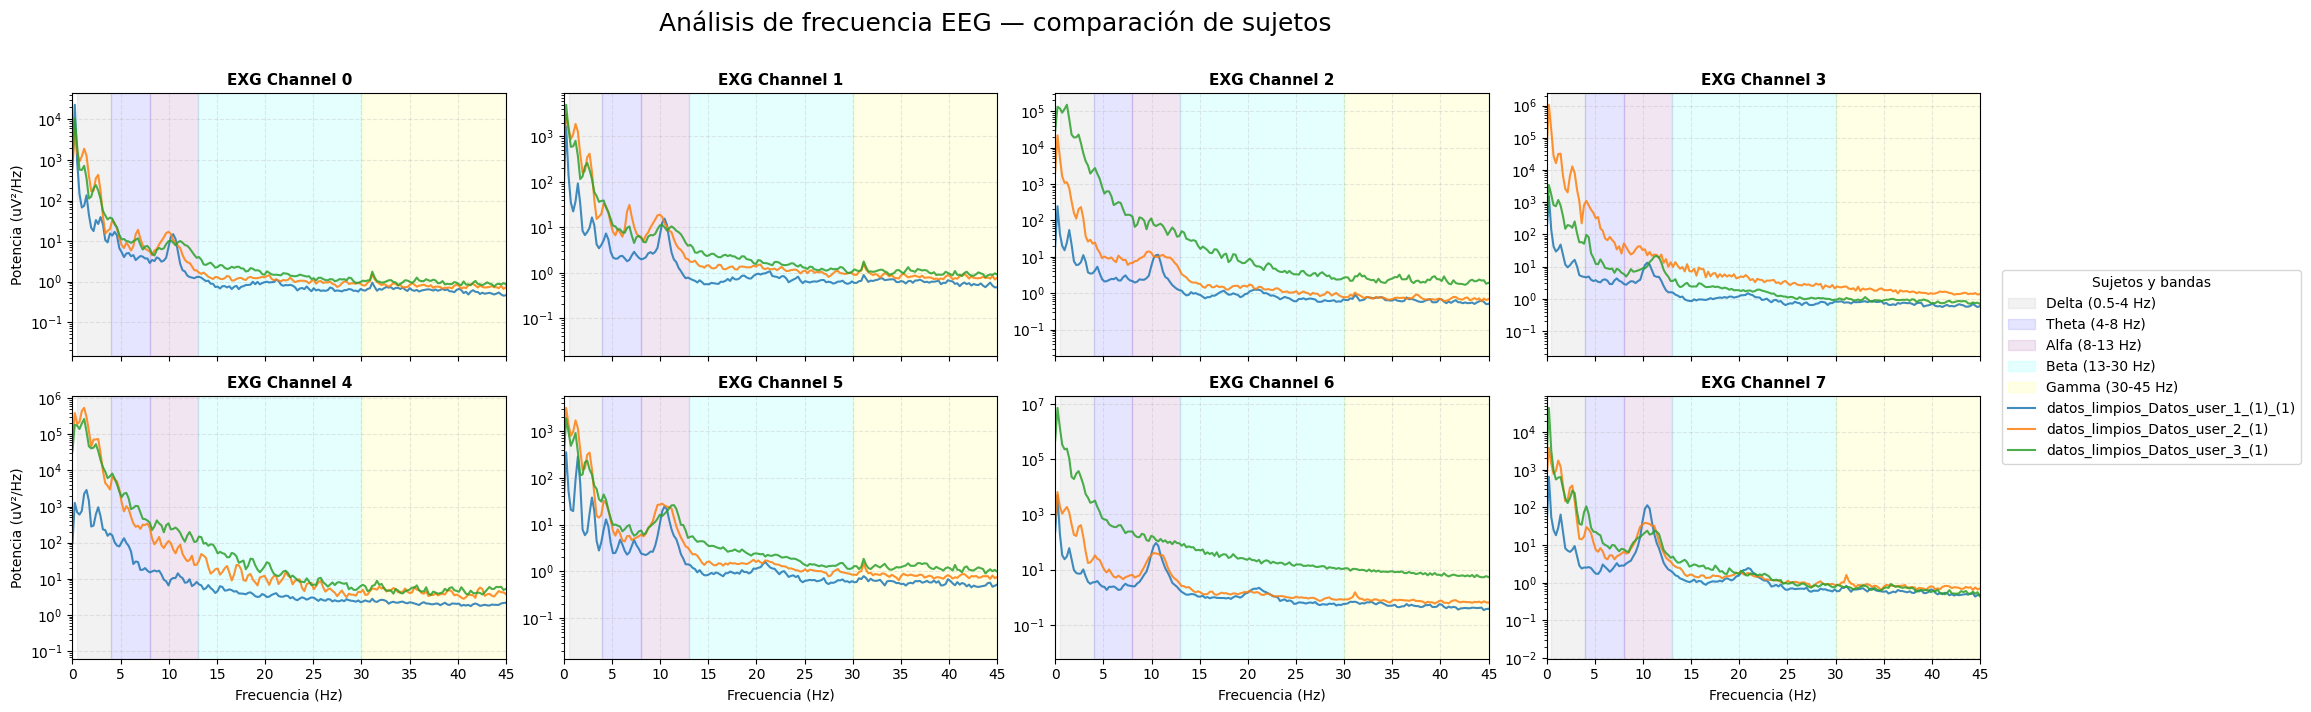

In [7]:
from scipy.signal import welch

BANDAS_EEG = {
    'Delta (0.5-4 Hz)': (0.5, 4,  'gray'),
    'Theta (4-8 Hz)':   (4,   8,  'blue'),
    'Alfa (8-13 Hz)':   (8,   13, 'purple'),
    'Beta (13-30 Hz)':  (13,  30, 'cyan'),
    'Gamma (30-45 Hz)': (30,  45, 'yellow'),
}

ncols = 4
nrows = int(np.ceil(len(CANALES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.5 * nrows), sharex=True)
fig.suptitle('Análisis de frecuencia EEG — comparación de sujetos', fontsize=18, y=1.01)
axes = np.atleast_1d(axes).flatten()
cmap = plt.colormaps.get_cmap('tab10')

for i, canal in enumerate(CANALES):
    ax = axes[i]
    for nombre_banda, (fmin, fmax, color) in BANDAS_EEG.items():
        ax.axvspan(fmin, fmax, color=color, alpha=0.10,
                   label=nombre_banda if i == 0 else None)

    for j, (sujeto, df) in enumerate(subjects_data.items()):
        if canal not in df.columns:
            continue
        señal = df[canal].dropna().to_numpy()
        if len(señal) == 0:
            continue
        f, psd = welch(señal, fs=FS, window='hamming', nperseg=1024)
        ax.plot(f, psd, color=cmap(j), alpha=0.85,
                label=sujeto if i == 0 else None)

    ax.set_title(canal, fontweight='bold', fontsize=11)
    ax.set_xlim(0, 45)
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.3)
    if i % ncols == 0:
        ax.set_ylabel('Potencia (uV²/Hz)')
    if i >= len(CANALES) - ncols:
        ax.set_xlabel('Frecuencia (Hz)')

for k in range(len(CANALES), len(axes)):
    fig.delaxes(axes[k])

fig.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Sujetos y bandas')
plt.tight_layout()
plt.show()

## 7. Band-pass Filtering (8–30 Hz)
4th order Butterworth with `filtfilt` (zero phase) over the Alpha + Beta bands.

In [8]:
from scipy.signal import butter, filtfilt


def filtro_pasabanda(datos, baja=BANDA_PASO[0], alta=BANDA_PASO[1], fs=FS, orden=4):
    nyquist = 0.5 * fs
    b, a = butter(orden, [baja / nyquist, alta / nyquist], btype='band')
    return filtfilt(b, a, datos)


subjects_data_filtrado = {}
for nombre, df in subjects_data.items():
    df_filt = df.copy()
    for canal in CANALES:
        df_filt[canal] = filtro_pasabanda(df[canal].fillna(0).to_numpy())
    subjects_data_filtrado[nombre] = df_filt
    print(f'Filtrado completado para {nombre}')

Filtrado completado para datos_limpios_Datos_user_1_(1)_(1)
Filtrado completado para datos_limpios_Datos_user_2_(1)
Filtrado completado para datos_limpios_Datos_user_3_(1)


## 8. Feature Extraction
Sliding windows of 1s with 50% overlap. Mean power in **Alpha** and **Beta** is calculated per window and channel → `2 x n_channels` features per window.

In [9]:
VENTANA = int(VENTANA_SEG * FS)
PASO    = int(SOLAPE_SEG * FS)


def extraer_caracteristicas(df, canales, ventana=VENTANA, paso=PASO, fs=FS):
    filas = []
    for inicio in range(0, len(df) - ventana + 1, paso):
        segmento_df = df.iloc[inicio:inicio + ventana]
        fila = []
        for canal in canales:
            f, psd = welch(segmento_df[canal].to_numpy(), fs=fs, nperseg=ventana)
            idx_alfa = (f >= BANDA_ALFA[0]) & (f <= BANDA_ALFA[1])
            idx_beta = (f >  BANDA_BETA[0]) & (f <= BANDA_BETA[1])
            fila.append(psd[idx_alfa].mean() if idx_alfa.any() else 0.0)
            fila.append(psd[idx_beta].mean() if idx_beta.any() else 0.0)
        filas.append(fila)
    return np.array(filas)


caracteristicas_por_sujeto = {}
for nombre, df in subjects_data_filtrado.items():
    caracteristicas_por_sujeto[nombre] = extraer_caracteristicas(df, CANALES)
    print(f'{nombre}: {caracteristicas_por_sujeto[nombre].shape[0]} ventanas '
          f'x {caracteristicas_por_sujeto[nombre].shape[1]} características')

datos_limpios_Datos_user_1_(1)_(1): 1325 ventanas x 16 características
datos_limpios_Datos_user_2_(1): 1322 ventanas x 16 características
datos_limpios_Datos_user_3_(1): 1328 ventanas x 16 características


## 9. Normalization and Final Matrix `X`
Standardization per subject (prevents amplitude differences between subjects from dominating) and concatenation.

In [10]:
from sklearn.preprocessing import StandardScaler

caracteristicas_norm = {}
scalers = {}

for nombre, matriz in caracteristicas_por_sujeto.items():
    scaler = StandardScaler()
    caracteristicas_norm[nombre] = scaler.fit_transform(matriz)
    scalers[nombre] = scaler
    print(f'{nombre} normalizado -> {caracteristicas_norm[nombre].shape}')

nombres_sujetos = list(caracteristicas_norm.keys())
X = np.vstack([caracteristicas_norm[n] for n in nombres_sujetos])

# Etiquetas de sujeto (solo para colorear las visualizaciones)
etiquetas_sujeto = np.concatenate([
    np.full(caracteristicas_norm[n].shape[0], i) for i, n in enumerate(nombres_sujetos)
])

print('\n--- MATRIZ FINAL ---')
print(f'Ventanas (ejemplos)  : {X.shape[0]}')
print(f'Características      : {X.shape[1]}')

datos_limpios_Datos_user_1_(1)_(1) normalizado -> (1325, 16)
datos_limpios_Datos_user_2_(1) normalizado -> (1322, 16)
datos_limpios_Datos_user_3_(1) normalizado -> (1328, 16)

--- MATRIZ FINAL ---
Ventanas (ejemplos)  : 3975
Características      : 16


## 10. Dimensionality Reduction
Four 2D projections colored by subject, to visually check if features separate information before grouping.

In [11]:
def graficar_proyeccion(X_2d, titulo, ejes=('Dim 1', 'Dim 2')):
    plt.figure(figsize=(10, 7))
    cmap = plt.colormaps.get_cmap('tab10')
    for i, nombre in enumerate(nombres_sujetos):
        pts = X_2d[etiquetas_sujeto == i]
        plt.scatter(pts[:, 0], pts[:, 1], color=cmap(i), label=nombre, alpha=0.6, s=15)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel(ejes[0]); plt.ylabel(ejes[1])
    plt.legend(title='Sujeto', markerscale=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 10.1 PCA

Varianza explicada: 65.7 %


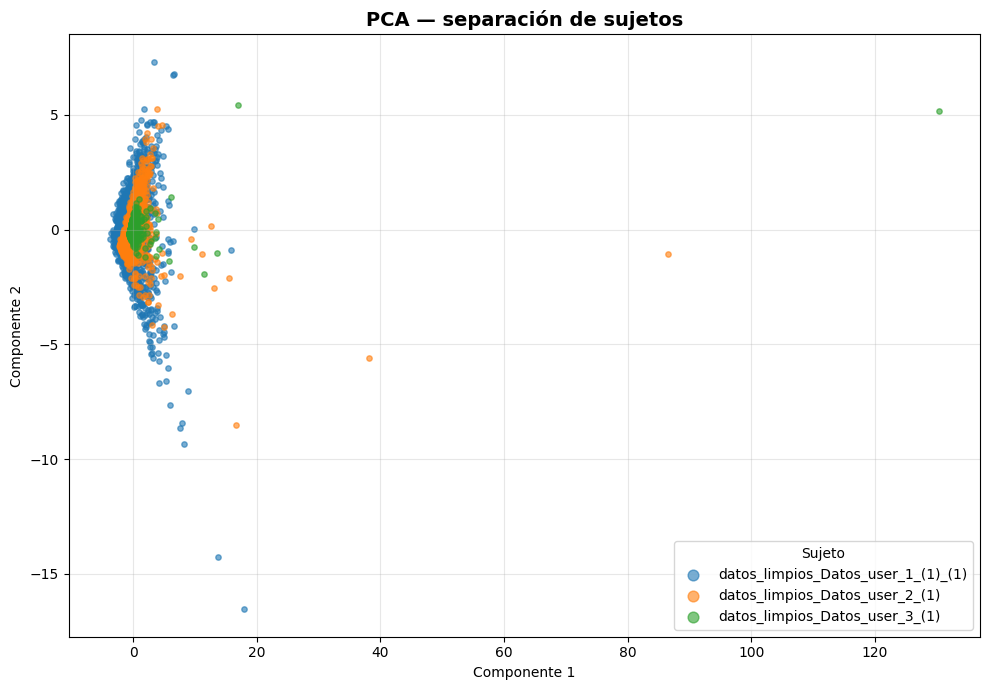

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f'Varianza explicada: {pca.explained_variance_ratio_.sum() * 100:.1f} %')

graficar_proyeccion(X_pca, 'PCA — separación de sujetos', ('Componente 1', 'Componente 2'))

### 10.2 t-SNE

t-SNE completado en 57.2 s


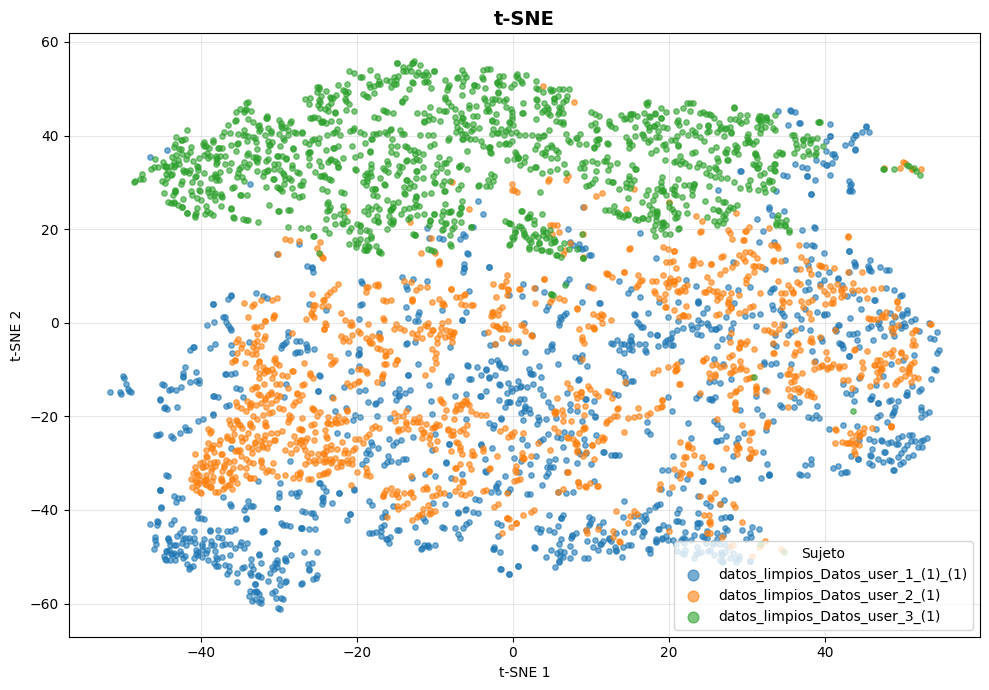

In [14]:
from sklearn.manifold import TSNE

t0 = time.time()
X_tsne = TSNE(n_components=2, perplexity=30, random_state=SEMILLA,
              init='pca', learning_rate='auto').fit_transform(X)
print(f't-SNE completado en {time.time() - t0:.1f} s')

graficar_proyeccion(X_tsne, 't-SNE', ('t-SNE 1', 't-SNE 2'))

### 10.3 UMAP

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completado en 37.7 s


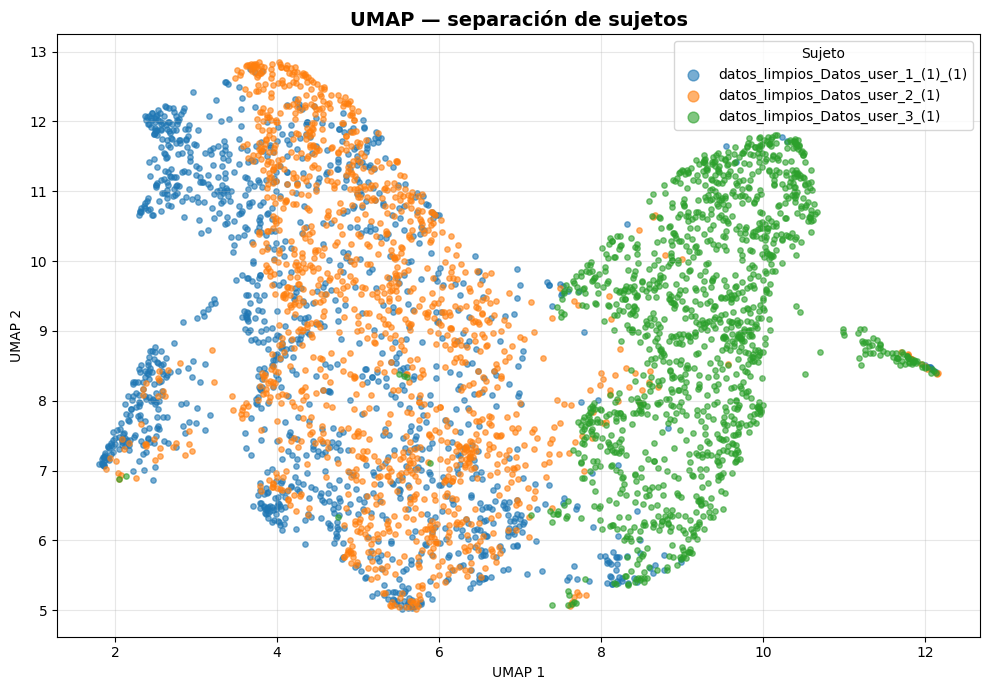

In [15]:
import umap

t0 = time.time()
X_umap = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST,
                   n_components=2, random_state=SEMILLA).fit_transform(X)
print(f'UMAP completado en {time.time() - t0:.1f} s')

graficar_proyeccion(X_umap, 'UMAP — separación de sujetos', ('UMAP 1', 'UMAP 2'))

### 10.4 Kernel PCA (RBF)

Kernel PCA completado en 0.7 s


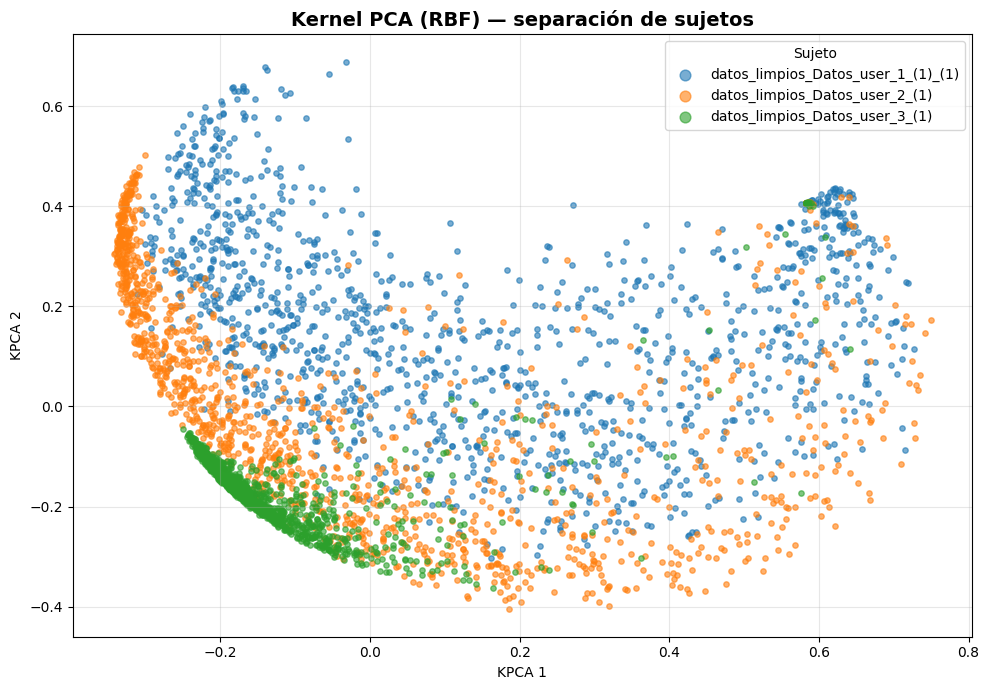

In [16]:
from sklearn.decomposition import KernelPCA

t0 = time.time()
X_kpca = KernelPCA(n_components=2, kernel='rbf', n_jobs=-1,
                   random_state=SEMILLA).fit_transform(X)
print(f'Kernel PCA completado en {time.time() - t0:.1f} s')

graficar_proyeccion(X_kpca, 'Kernel PCA (RBF) — separación de sujetos', ('KPCA 1', 'KPCA 2'))

## 11. Clustering: UMAP + K-Means Pipeline
Train/test split (80/20), UMAP reduction, and grouping into 5 clusters within a single `Pipeline`, so that the reduction is learned **only** from the training data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

X_train, X_test = train_test_split(X, test_size=TEST_SIZE, random_state=SEMILLA)
print(f'Entrenamiento : {X_train.shape[0]} ventanas')
print(f'Prueba        : {X_test.shape[0]} ventanas\n')

pipeline_eeg = Pipeline([
    ('reductor_umap', umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST,
                                n_components=2, random_state=SEMILLA)),
    ('modelo_kmeans', KMeans(n_clusters=N_CLUSTERS, random_state=SEMILLA, n_init=20)),
])

print('Entrenando pipeline (UMAP + K-Means)...')
pipeline_eeg.fit(X_train)

reductor = pipeline_eeg.named_steps['reductor_umap']
etiquetas_train = pipeline_eeg.predict(X_train)
etiquetas_test  = pipeline_eeg.predict(X_test)
X_train_2d = reductor.transform(X_train)
X_test_2d  = reductor.transform(X_test)

score = silhouette_score(X_test_2d, etiquetas_test)
print(f'\nSilhouette Score (test): {score:.3f}\n')

print('--- DISTRIBUCIÓN DE CLÚSTERES (TEST) ---')
for i in range(N_CLUSTERS):
    n = int(np.sum(etiquetas_test == i))
    print(f'{NOMBRES_MOV[i]}: {n} ventanas ({n / len(etiquetas_test) * 100:.1f} %)')

Entrenamiento : 3180 ventanas
Prueba        : 795 ventanas

Entrenando pipeline (UMAP + K-Means)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Silhouette Score (test): 0.405

--- DISTRIBUCIÓN DE CLÚSTERES (TEST) ---
Movimiento A: 172 ventanas (21.6 %)
Movimiento B: 187 ventanas (23.5 %)
Movimiento C: 150 ventanas (18.9 %)
Movimiento D: 138 ventanas (17.4 %)
Movimiento E: 148 ventanas (18.6 %)


## 12. Evaluation and Cluster Visualization

### 12.1 Clusters in Training and Testing

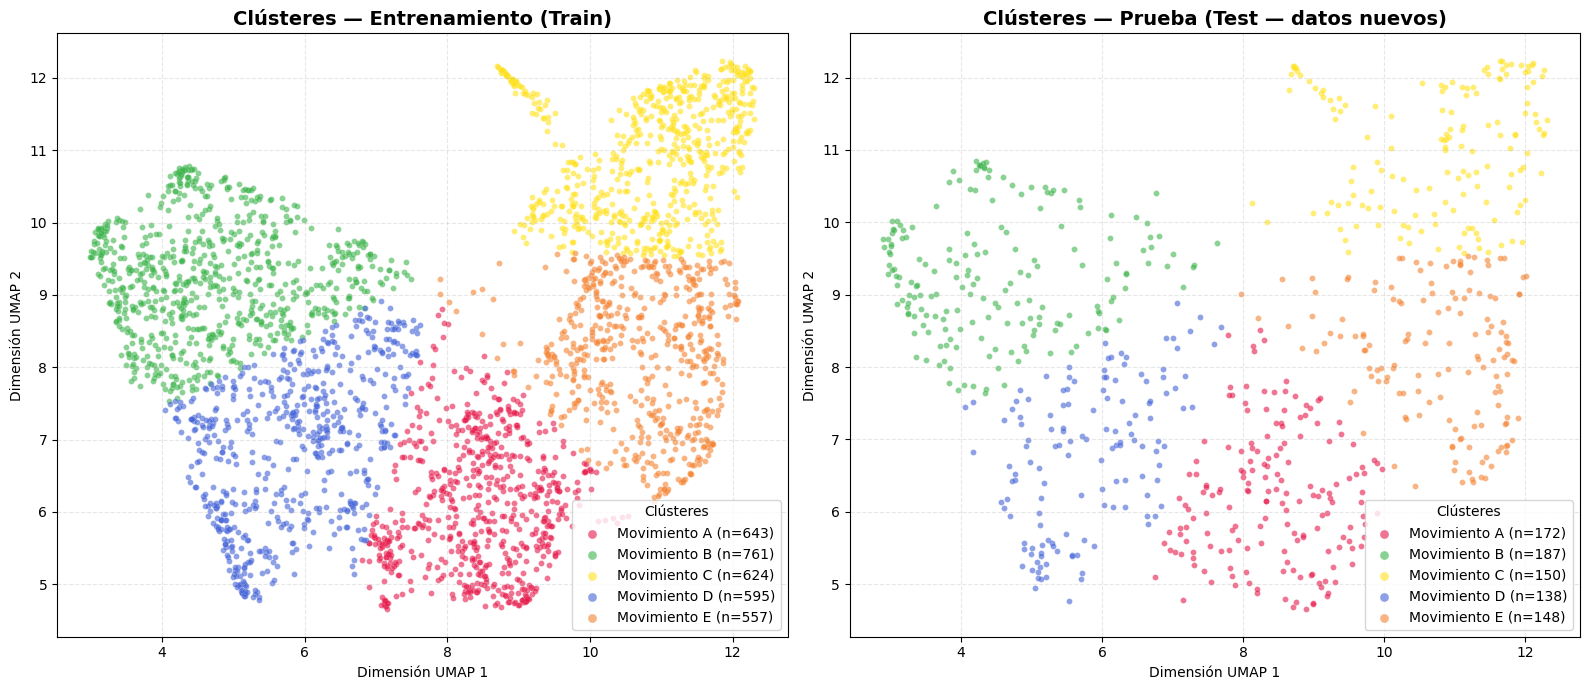

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, X_2d, etiquetas, titulo in [
    (axes[0], X_train_2d, etiquetas_train, 'Entrenamiento (Train)'),
    (axes[1], X_test_2d,  etiquetas_test,  'Prueba (Test — datos nuevos)'),
]:
    for i in range(N_CLUSTERS):
        pts = X_2d[etiquetas == i]
        ax.scatter(pts[:, 0], pts[:, 1], c=COLORES_MOV[i],
                   label=f'{NOMBRES_MOV[i]} (n={len(pts)})',
                   alpha=0.6, s=18, edgecolors='w', linewidth=0.1)
    ax.set_title(f'Clústeres — {titulo}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dimensión UMAP 1'); ax.set_ylabel('Dimensión UMAP 2')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(title='Clústeres', markerscale=1.5)

plt.tight_layout()
plt.show()

### 12.2 Silhouette Plot

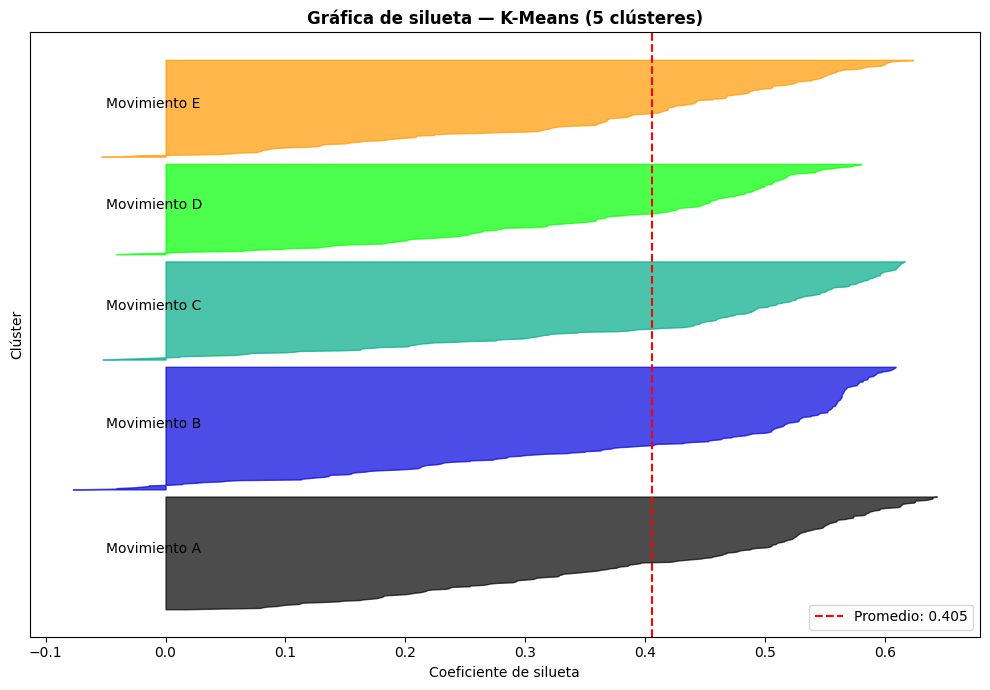

In [19]:
import matplotlib.cm as cm

valores_silueta = silhouette_samples(X_test_2d, etiquetas_test)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(N_CLUSTERS):
    valores_i = np.sort(valores_silueta[etiquetas_test == i])
    y_upper = y_lower + len(valores_i)
    color = cm.nipy_spectral(i / N_CLUSTERS)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_i,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(valores_i), NOMBRES_MOV[i])
    y_lower = y_upper + 10

ax.axvline(x=score, color='red', linestyle='--', label=f'Promedio: {score:.3f}')
ax.set_title(f'Gráfica de silueta — K-Means ({N_CLUSTERS} clústeres)', fontweight='bold')
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Clúster')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()